In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer, LabelEncoder
#from sklearn import metrics 
from xailib.data_loaders.dataframe_loader import prepare_dataframe

 
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
 
from sklearn.compose import make_column_selector as selector

from lore_sa.dataset import TabularDataset
from lore_sa.surrogate import DecisionTreeSurrogate

import matplotlib.pyplot as plt
from datetime import datetime, timedelta


2024-06-04 10:23:19,511 matplotlib   DEBUG    matplotlib data path: /opt/anaconda3/envs/xai/lib/python3.8/site-packages/matplotlib/mpl-data
2024-06-04 10:23:19,518 matplotlib   DEBUG    CONFIGDIR=/Users/eleonoracappuccio/.matplotlib
2024-06-04 10:23:19,521 matplotlib   DEBUG    interactive is False
2024-06-04 10:23:19,522 matplotlib   DEBUG    platform is darwin
2024-06-04 10:23:19,599 matplotlib   DEBUG    CACHEDIR=/Users/eleonoracappuccio/.matplotlib
2024-06-04 10:23:19,604 matplotlib.font_manager DEBUG    Using fontManager instance from /Users/eleonoracappuccio/.matplotlib/fontlist-v330.json


In [3]:
df = pd.read_csv("../../datasets/Final_data.csv")

df.head()

,Unnamed: 0,id,Name,Sequence ID,Province name,Class_label,Start time,End time,Duration,Temporal context start,...,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,Week5_Covid_encoded,Week3_Covid_encoded,Covid_trend,Days_passed
0,1,01_c1_12_20/04/2020_12/07/2020,NaN,1,Araba/ lava,c1,20/04/2020,12/7/2020,84,9/3/2020,...,m4,m1,m1,m1,m1,m1,4,3,D,63.0
1,3,01_c2_1_13/04/2020..19/04/2020,NaN,1,Araba/ lava,c2,13/04/2020,19/04/2020,7,2/3/2020,...,m4,m4,m1,m1,m1,m1,4,4,S,56.0
2,4,01_c2_2_13/07/2020_26/07/2020,NaN,1,Araba/ lava,c2,13/07/2020,26/07/2020,14,1/6/2020,...,m3,m3,m3,m3,m3,m3,1,1,S,147.0
3,6,01_c3_2_30/03/2020_12/04/2020,NaN,1,Araba/ lava,c3,30/03/2020,12/4/2020,14,17/02/2020,...,m4,m4,m4,m4,m1,m1,2,4,I,42.0
4,7,01_c3_2_27/07/2020_09/08/2020,NaN,1,Araba/ lava,c3,27/07/2020,9/8/2020,14,15/06/2020,...,m3,m3,m3,m3,m3,m3,1,1,S,161.0


In [ ]:
df = df.loc[:,['Class_label','Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week5_Mobility','Week4_Mobility','Week3_Mobility','Week2_Mobility', 'Days_passed', 'Duration']]
 
mask = df.drop(["Class_label"], axis=1).isna().all(axis=1) & df['Class_label'].notna()
result_df = df[~mask]
#df = df.dropna(how = 'all')
result_df = result_df.fillna("NONE")

In [3]:
result_df.head()

,Class_label,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,c1,c4,c4,c3,m1,m1,m1,m1,63.0,84
1,c2,c4,c4,c4,m4,m1,m1,m1,56.0,7
2,c2,c1,c1,c1,m3,m3,m3,m3,147.0,14
3,c3,c2,c3,c4,m4,m4,m4,m1,42.0,14
4,c3,c1,c1,c1,m3,m3,m3,m3,161.0,14


In [4]:
y = result_df["Class_label"].values
X_feat = result_df.loc[:,'Week5_Covid':'Duration']

In [5]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

In [6]:
numerical_columns = numerical_columns_selector(X_feat)
categorical_columns = categorical_columns_selector(X_feat)

In [7]:
covid_categories = ['NONE', 'c1', 'c2', 'c3', 'c4']
mobility_categories = ['NONE','m1', 'm2', 'm3', 'm4']
 
enc = OrdinalEncoder(categories=[covid_categories,covid_categories,covid_categories, mobility_categories,mobility_categories,mobility_categories,mobility_categories])
numerical_preprocessor = StandardScaler()

In [8]:
preprocessor = ColumnTransformer(
    [
        ("ordinal-encoder", enc, categorical_columns),
        ("standard_scaler", numerical_preprocessor, numerical_columns),
    ]
)

In [9]:
clf = RandomForestClassifier(n_estimators = 100, random_state=0)
model = make_pipeline(preprocessor, clf)
 
#y_prediction = cross_val_predict(model, X_feat,y, cv=5)
#acc = cross_val_score(model, X_feat,y, cv=5)

In [10]:
data_train, data_test, target_train, target_test = train_test_split(
    X_feat, y, random_state=0
)

In [11]:
data_train

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
255,c1,c1,c2,m4,m4,m4,m1,42.0,7
229,c3,c3,c3,m3,m2,m3,m3,322.0,35
300,c3,c3,c3,m2,m3,m2,m2,329.0,21
7,c3,c4,c4,m2,m3,m3,m3,357.0,49
160,c1,c1,c2,m4,m4,m4,m1,42.0,21
...,...,...,...,...,...,...,...,...,...
323,c3,c3,c3,m3,m3,m3,m4,224.0,63
192,c1,c1,c1,m4,m4,m4,m4,182.0,42
117,c3,c4,c4,m3,m4,m4,m4,273.0,28
47,c3,c4,c4,m3,m4,m4,m3,273.0,21


In [12]:
_ = model.fit(data_train, target_train)
 
y_predict = model.predict(data_test)
 
print(model.score(data_test, target_test))

0.8888888888888888


2024-05-29 14:26:23,028 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7fd54bc44fd0>


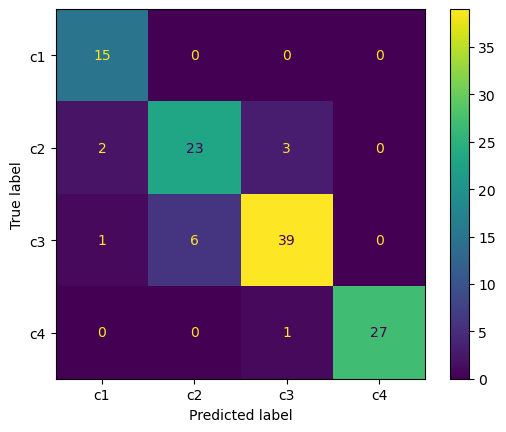

In [14]:
predictions = model.predict(data_test)
cm = confusion_matrix(target_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


# Neighborhood generation

In [15]:
generator_ordinal=data_train.loc[:,'Week5_Covid':'Week2_Mobility']
generator_ordinal= enc.fit_transform(generator_ordinal)

In [16]:
generator_preprocessor = ColumnTransformer(
    transformers = [
        ("ordinal-encoder", enc, categorical_columns),
    ],
    remainder='passthrough'
)

In [17]:
generator_data = generator_preprocessor.fit_transform(data_train)

In [18]:
generator_data

array([[  1.,   1.,   2., ...,   1.,  42.,   7.],
       [  3.,   3.,   3., ...,   3., 322.,  35.],
       [  3.,   3.,   3., ...,   2., 329.,  21.],
       ...,
       [  3.,   4.,   4., ...,   4., 273.,  28.],
       [  3.,   4.,   4., ...,   3., 273.,  21.],
       [  1.,   2.,   2., ...,   3., 168.,  28.]])

In [19]:
generator_data[95]

array([  3.,   3.,   3.,   3.,   3.,   3.,   3., 413.,  28.])

### Generator

In [159]:
import random
class NewGenElegant:
    def __init__(self):
        self.gen_data = None
 
    def perturb(self, x, num_instances):
        perturbed_arrays = []

        choices = [0, 1, 2, 3, 4]
        
        covid_weights = [
            [0.0, 0.25, 0.13, 0.36, 0.26], #0
            [0.0, 0.40, 0.30, 0.20, 0.10], #1
            [0.0, 0.25, 0.40, 0.25, 0.10], #2
            [0.0, 0.10, 0.25, 0.40, 0.25], #3
            [0.0, 0.10, 0.20, 0.30, 0.40], #4
        ]

        mobility_weights=[
            [0.0, 0.12, 0.18, 0.45, 0.24], #0
            [0.0, 0.40, 0.30, 0.20, 0.10], #1
            [0.0, 0.25, 0.40, 0.25, 0.10],#2
            [0.0, 0.10, 0.25, 0.40, 0.25], #3
            [0.0, 0.10, 0.20, 0.30, 0.40] #4
        
        ]

        for _ in range(num_instances):
            perturbed_arr = x[:]
    
            for val in range(0,3): #covid
                perturbed_arr[val] = random.choices(choices, weights = covid_weights[val])[0]
                
            for val in range(3, 7): #mobility
                perturbed_arr[val] = random.choices(choices, weights = mobility_weights[val-3])[0]
                    
            perturbed_arr[7]= random.choice(range(42, 442, 7)) 
            perturbed_arr[8]= random.choice(range(7, 148, 7))
                 
            perturbed_arrays.append(perturbed_arr)
        self.gen_data = perturbed_arrays
        return perturbed_arrays
 
 
# Example usage:
 
 
x =list(generator_data[95])
perturber = NewGenElegant()
n = 100
perturbed_arrays = perturber.perturb(x=x, num_instances=n)
for perturbed_arr in perturbed_arrays:
    print(perturbed_arr)

[3, 1, 4, 1, 2, 2, 4, 133, 126]
[4, 1, 2, 4, 2, 1, 3, 56, 98]
[2, 1, 2, 3, 2, 2, 3, 112, 105]
[3, 1, 2, 1, 3, 1, 4, 259, 63]
[3, 3, 3, 3, 1, 1, 3, 154, 28]
[2, 1, 3, 3, 1, 2, 2, 378, 14]
[3, 4, 2, 1, 4, 4, 4, 273, 126]
[3, 1, 2, 3, 1, 2, 3, 371, 119]
[1, 1, 2, 4, 1, 2, 4, 154, 112]
[1, 1, 1, 3, 1, 3, 2, 392, 56]
[1, 2, 1, 3, 1, 2, 4, 315, 147]
[4, 3, 2, 3, 2, 2, 4, 406, 126]
[1, 3, 2, 4, 1, 4, 2, 378, 7]
[1, 1, 2, 3, 1, 2, 3, 392, 35]
[4, 3, 2, 3, 2, 2, 1, 427, 112]
[3, 1, 1, 4, 2, 4, 2, 133, 98]
[3, 1, 1, 3, 3, 4, 4, 224, 105]
[1, 4, 3, 4, 1, 3, 4, 413, 119]
[4, 1, 2, 3, 2, 1, 1, 378, 119]
[2, 1, 1, 1, 2, 1, 4, 238, 105]
[3, 3, 2, 2, 2, 2, 4, 245, 63]
[3, 2, 3, 3, 4, 3, 3, 413, 98]
[1, 2, 2, 3, 4, 1, 2, 84, 147]
[3, 3, 1, 2, 1, 3, 2, 266, 126]
[1, 3, 2, 3, 1, 2, 3, 196, 105]
[4, 3, 2, 4, 1, 1, 4, 273, 56]
[2, 1, 4, 3, 1, 3, 3, 210, 21]
[1, 3, 2, 1, 1, 2, 4, 112, 119]
[1, 2, 4, 4, 1, 2, 2, 357, 35]
[3, 4, 2, 2, 3, 3, 3, 133, 119]
[3, 3, 2, 2, 1, 2, 3, 98, 7]
[3, 2, 2, 3, 2, 4, 1, 336, 

In [160]:
columns=X_feat.columns

In [161]:
columns

Index(['Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week5_Mobility',
       'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Days_passed',
       'Duration'],
      dtype='object')

In [162]:
neighbour_df_95 = pd.DataFrame(perturbed_arrays, columns=columns)
neighbour_df_95.head()

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,3,1,4,1,2,2,4,133,126
1,4,1,2,4,2,1,3,56,98
2,2,1,2,3,2,2,3,112,105
3,3,1,2,1,3,1,4,259,63
4,3,3,3,3,1,1,3,154,28


We now use the black box we created before to classify all the instances of the new synthetic dataset

In [163]:
neighbour_df_95.to_csv('../../datasets/neighbourhood_95.csv', index=False)  
neighbour=TabularDataset.from_csv('../../datasets/neighbourhood_95.csv')

2024-05-29 14:51:04,526 root         WARNING  No target class is defined
2024-05-29 14:51:04,527 root         INFO     ../../datasets/neighbourhood_95.csv file imported


In [164]:
neighbour.df

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,3,1,4,1,2,2,4,133,126
1,4,1,2,4,2,1,3,56,98
2,2,1,2,3,2,2,3,112,105
3,3,1,2,1,3,1,4,259,63
4,3,3,3,3,1,1,3,154,28
...,...,...,...,...,...,...,...,...,...
95,3,1,2,3,3,1,4,119,42
96,1,2,4,2,2,2,2,112,42
97,4,4,4,3,3,2,3,126,98
98,1,1,1,3,1,3,3,406,56


In [165]:
from lore_sa.bbox import sklearn_classifier_bbox

In [166]:
bbox = sklearn_classifier_bbox.sklearnBBox(clf)

In [167]:
neighbour.df['Class_label'] = bbox.predict(neighbour.df)
neighbour.set_class_name('Class_label')

/opt/anaconda3/envs/xai/lib/python3.8/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [168]:
le=LabelEncoder()
neighbour.df['Class_label'] = le.fit_transform(neighbour.df['Class_label']) 
neighbour.df['Class_label']

0     2
1     2
2     2
3     2
4     2
     ..
95    2
96    2
97    1
98    2
99    2
Name: Class_label, Length: 100, dtype: int64

In [169]:
neighbour.df

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration,Class_label
0,3,1,4,1,2,2,4,133,126,2
1,4,1,2,4,2,1,3,56,98,2
2,2,1,2,3,2,2,3,112,105,2
3,3,1,2,1,3,1,4,259,63,2
4,3,3,3,3,1,1,3,154,28,2
...,...,...,...,...,...,...,...,...,...,...
95,3,1,2,3,3,1,4,119,42,2
96,1,2,4,2,2,2,2,112,42,2
97,4,4,4,3,3,2,3,126,98,1
98,1,1,1,3,1,3,3,406,56,2


### Add start date and end date

In [170]:
base_date = datetime(2020, 2, 17)

In [171]:
neighbour.df['Start_date'] = neighbour.df['Days_passed'].apply(lambda x: base_date + timedelta(days=x))
neighbour.df['End_date'] = neighbour.df.apply(lambda row: row['Start_date'] + timedelta(days=row['Duration']), axis=1)

In [172]:
neighbour.df.head(50)

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration,Class_label,Start_date,End_date
0,3,1,4,1,2,2,4,133,126,2,2020-06-29,2020-11-02
1,4,1,2,4,2,1,3,56,98,2,2020-04-13,2020-07-20
2,2,1,2,3,2,2,3,112,105,2,2020-06-08,2020-09-21
3,3,1,2,1,3,1,4,259,63,2,2020-11-02,2021-01-04
4,3,3,3,3,1,1,3,154,28,2,2020-07-20,2020-08-17
5,2,1,3,3,1,2,2,378,14,2,2021-03-01,2021-03-15
6,3,4,2,1,4,4,4,273,126,2,2020-11-16,2021-03-22
7,3,1,2,3,1,2,3,371,119,2,2021-02-22,2021-06-21
8,1,1,2,4,1,2,4,154,112,2,2020-07-20,2020-11-09
9,1,1,1,3,1,3,2,392,56,2,2021-03-15,2021-05-10


### Export the neigh dataframe

In [173]:
n_neigh=95

In [174]:
output_path=f'../../datasets/neighbourhood_gen/neighbourhood_{n_neigh}.csv'
neighbour.df.to_csv(output_path)

### GENERATE RULES

In [30]:
features = [c for c in neighbour.df.columns if c != neighbour.class_name]

In [31]:
surrogate = DecisionTreeSurrogate()
surrogate.train(neighbour.df[features].values , neighbour.df['Class_label'] )

DecisionTreeClassifier()

In [32]:
decoded_n = enc.inverse_transform(neighbour.df.iloc[:, :7])

In [33]:
from lore_sa.encoder_decoder import EncDec
class IdentityEncoder(EncDec):
    """
    It provides an interface to access Identity encoding functions.
    """
    def __init__(self,dataset_descriptor):
        super().__init__(dataset_descriptor)

    def encode(self, x: np.array) -> np.array:
        """
        It applies the encoder to the input features

        :param [Numpy array] x: Array to encode
        :return [Numpy array]: Encoded array
        """
        return x

    def get_encoded_features(self):
        """
        Provides a dictionary with the new encoded features name and the new index
        :return:
        """
        return self.encoded_features

    def decode(self, x: np.array) -> np.array:
        return x

    def decode_target_class(self, x: np.array):
        return x

In [43]:
result_df.columns

Index(['Class_label', 'Week5_Covid', 'Week4_Covid', 'Week3_Covid',
       'Week5_Mobility', 'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility',
       'Days_passed', 'Duration'],
      dtype='object')

In [47]:
enc_result_df = generator_preprocessor.fit_transform(result_df)
enc_result_df=pd.DataFrame(enc_result_df, columns=result_df.columns)

In [48]:
enc_dataset = TabularDataset(enc_result_df, class_name="Class_label")

In [49]:
enc_dataset.descriptor

{'numeric': {},
 'categorical': {'Week5_Covid': {'index': 0,
   'distinct_values': [4.0, 1.0, 3.0, 2.0],
   'count': {4.0: 133, 1.0: 100, 3.0: 166, 2.0: 69}},
  'Week4_Covid': {'index': 1,
   'distinct_values': [3.0, 4.0, 1.0, 2.0],
   'count': {3.0: 173, 4.0: 127, 1.0: 81, 2.0: 87}},
  'Week3_Covid': {'index': 2,
   'distinct_values': [1.0, 4.0, 3.0, 2.0],
   'count': {1.0: 54, 4.0: 115, 3.0: 215, 2.0: 84}},
  'Week5_Mobility': {'index': 3,
   'distinct_values': [1.0, 3.0, 4.0, 2.0],
   'count': {1.0: 66, 3.0: 214, 4.0: 111, 2.0: 77}},
  'Week4_Mobility': {'index': 4,
   'distinct_values': [1.0, 3.0, 4.0, 2.0],
   'count': {1.0: 81, 3.0: 205, 4.0: 109, 2.0: 73}},
  'Week3_Mobility': {'index': 5,
   'distinct_values': [1.0, 3.0, 2.0, 4.0],
   'count': {1.0: 97, 3.0: 212, 2.0: 72, 4.0: 87}},
  'Week2_Mobility': {'index': 6,
   'distinct_values': ['c1', 'c2', 'c3', 'c4'],
   'count': {'c1': 54, 'c2': 127, 'c3': 182, 'c4': 105}},
  'Days_passed': {'index': 7,
   'distinct_values': [63.0,


In [50]:
x = decoded_n[5]
x1=neighbour.df[features].iloc[5].values
rule = surrogate.get_rule(x1, neighbour, IdentityEncoder(enc_dataset.descriptor))
print(rule)

rule.variable: Days_passed


IndexError: list index out of range

In [ ]:
neighbour_df_5.to_csv('../../datasets/neighbourhood_95.csv', index=False) 